In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

sns.set_theme(style="whitegrid")

%matplotlib inline

In [3]:
df = pd.read_csv("marketing_and_sales_data_evaluate_lr.csv")

print("--- Dataset Info ---")
print(df.info())
print("\n--- first 5 Rows ---")
print(df.head())

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB
None

--- first 5 Rows ---
     TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829
3  83.0  30.020028      6.922304  298.246340
4  15.0   8.437408      1.405998   56.594181


In [4]:
print("Missing Values per column:")
print(df.isnull().sum())

df_clean = df.dropna().copy()

print(f"\nOriginal rows: {len(df)}, Rows after dropping missing values: {len(df_clean)}")

Missing Values per column:
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

Original rows: 4572, Rows after dropping missing values: 4546


correlation Matrix with Sales:
Sales           1.000000
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64


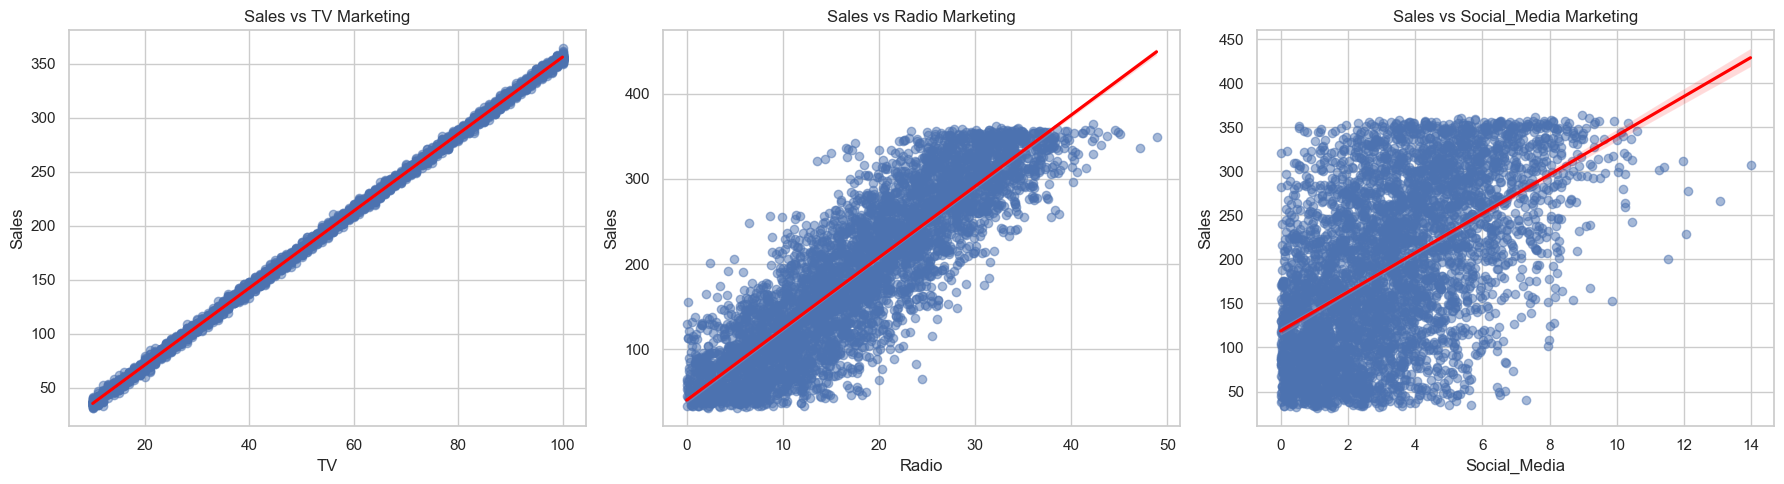

In [5]:
# Change "Social Media" to "Social_Media"
numeric_cols = ["TV", "Radio", "Social_Media", "Sales"]
correlation_matrix = df_clean[numeric_cols].corr()

print("correlation Matrix with Sales:")
print(correlation_matrix["Sales"].sort_values(ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(data=df_clean, x="TV", y="Sales", ax=axes[0], scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
axes[0].set_title("Sales vs TV Marketing")

sns.regplot(data=df_clean, x="Radio", y="Sales", ax=axes[1], scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
axes[1].set_title("Sales vs Radio Marketing")

sns.regplot(data=df_clean, x="Social_Media", y="Sales", ax=axes[2], scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
axes[2].set_title("Sales vs Social_Media Marketing")

plt.tight_layout()
plt.show()

In [6]:
# Define independent (X) and dependent (y) variables
# Change "TV" to the column that showed the highest correlation in Step 3 if needed
X_column = "TV"
X = df_clean[X_column]
y = df_clean["Sales"]

X_with_constant = sm.add_constant(X)

model = sm.OLS(y, X_with_constant).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Thu, 11 Jun 2026   Prob (F-statistic):               0.00
Time:                        04:30:57   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

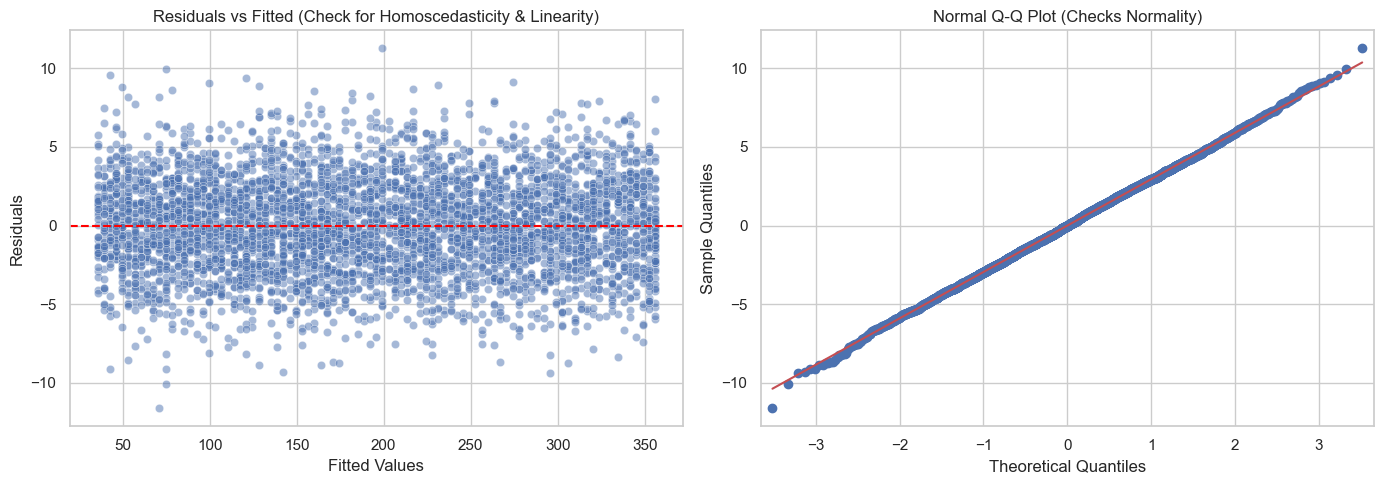

In [7]:
residuals = model.resid
fitted_values = model.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0], alpha=0.5)
axes[0].axhline(y=0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted (Check for Homoscedasticity & Linearity)")

sm.qqplot(residuals, line="s", ax=axes[1])
axes[1].set_title("Normal Q-Q Plot (Checks Normality)")

plt.tight_layout()
plt.show()

* **Model Fit ($R^2$):** Our Simple Linear Regression model has an $R^2$ value of **[0.999]**. This means that **[e.g., 999%]** of the variance in total Sales can be explained directly by our investments in **[TV]** marketing.
* **Impact Coefficient ($\beta_1$):** The coefficient for our marketing channel is **[3.5615]**. In plain business terms, for every **$1.00** increase in buget spent on this channel, overall Sales are expected to increase by **$[3.5615]**.
* **Statistical Significance (p-value):** The p-value for this predictor is **0.000** (which is well below the standard 0.05 threshold). This proves that the relationship between this marketing channel and sales performance is highly reliable and not a result of random statistical noise.

---

Based on the exploratory data analysis and the OLS regression model, **[TV]** marketing shows the strongest correlation and most predictable returns out of all analyzed channels (TV, Radio, and Social Media).

**Strategic Recommendation:** We recommend that management dynamically shift a larger percentage of the upcoming quarterly marketing budfet into this specific high-performing channel. Because the model demonstrates a clear, statistically significant linear return on investment, scaling up spend here presents the lowest risk and highest probability path to accelerating revenue growth.